**Analysis of Alveolar Type II Cell Transcriptional States in Lethal COVID-19 Lung Biopsies**

by Ashley Ramsawhook, PhD.

This work is an independent analysis of the Alveolar Type II (AT2) cell transcriptional state in lethal COVID-19 lung biopsies taken from Melms *et al*, 2021 (https://doi.org/10.1038/s41586-021-03569-1). While this notebook reproduces and modifies the pre-processing steps of the raw data performed by the authors, the exploration, analysis, deductions and conclusion are independent and self-directed. The agentic Large Language Model (LLM), Claude Sonnet 5.0 (Anthropic) was utilised for code debugging, statistical methodology discussions and literature dataset navigation. All code and markdown were written by myself.



**The Dataset**

The Melms *et al*, 2021 dataset consisted of lung biopsies extracted from 7 healthy donors and 19 COVID patients harvested post-mortem and sequencing libraries were prepared from single nuclei suspensions. Only one biopsy was harvested per donor, making the terms “Sample” and “Donor” synonymous for this dataset. Ambient RNA and debris contamination had been excluded from raw counts by the authors using CELL BENDER prior to publication of the dataset.   

**External Resources for Annotation**

A curated list of human ribosomal genes was acquired from the Broad Institute's software repository: http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt

**Installing Necessary Libraries and Dependencies**

In [ ]:
%pip install scanpy

In [ ]:
%pip install scvi-tools

In [ ]:
%pip install scikit-misc

In [ ]:
! pip install leidenalg

In [ ]:
! pip install gseapy

In [ ]:
! pip install celltypist --break-system-packages

In [ ]:
! pip install pydeseq2 

**Import the Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import scipy
import glob
from pathlib import Path
import seaborn as sns
from scipy.sparse import csr_matrix, issparse
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
import gseapy as gp
from scipy import stats
import celltypist
from celltypist import models
import requests
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

**Setting the File Paths for Reading-in and Saving Data** 

In [2]:
from pathlib import Path

In [3]:
#Setting the input data path which contains the raw counts files
DATA_DIR = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/unzipped raw counts")
files = list(DATA_DIR.glob("*.csv"))

In [4]:
#Setting the output path for saving models and processed files
OUTPUT_DIR = "E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/processed"

**Import the Curated Geneset for Ribosomal Gene Annotation**



In [5]:
#Import the Broad Institute's Ribosomal Geneset
RIBO_LIST = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/KEGG_RIBOSOME.v2026.1.Hs.txt" )
ribo_genes = pd.read_table(RIBO_LIST, skiprows=2, header= None)

**Analysis**

**Counting Cells**

Following cluster cell type assignment, cell types were counted to assess their representation between healthy and COVID-19 conditions. 

In [ ]:
#Check unique samples
adata_combined.obs.Sample.unique().tolist()

Create a function to map sample condition ("Control" or "COVID19") to donor samples

In [12]:
#Map sample suffix rename function
def map_condition(x):
    """This function maps uses the sample name suffix to determine whether the donor sample should be labelled as a Control or 
    COVID19 condition. The function returns a 'COVID' label if 'cov' is present in the donor sample name, otherwise it
     returns 'Control' """

    if "cov" in x:
        return "COVID19"
    else:
        return "Control"

In [13]:
#Create a new feature in the adata_combined observations layer to store the condition labels

adata_combined.obs["condition"] = adata_combined.obs.Sample.map(map_condition)
adata_combined.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_MT,pct_counts_MT,total_counts_ribo,pct_counts_ribo,batch,...,PSME4_scvi_norm,KIF13B_scvi_norm,CHD2_scvi_norm,ABCA9_scvi_norm,LTBP2_scvi_norm,ABCA6_scvi_norm,WIF1_scvi_norm,celltypist_label,cell_type,condition
TAAGCACTCTCACGAA-1_1-C51ctr,C51ctr,False,1956,1956,4298.0,2.0,0.046533,5.0,0.116333,C51ctr,...,1.959837,1.046846,7.264519,0.068970,0.005024,0.015020,4.380715,AT2,Alveolar Type II Cells,Control
CACAACAGTACCCAGC-1_1-C51ctr,C51ctr,False,1913,1913,4198.0,0.0,0.000000,2.0,0.047642,C51ctr,...,2.250821,1.362438,8.648341,0.057681,0.009199,0.017711,4.947580,AT2,Alveolar Type II Cells,Control
TTGCATTAGCTAGCCC-1_1-C51ctr,C51ctr,False,1935,1935,4054.0,1.0,0.024667,1.0,0.024667,C51ctr,...,1.739881,1.892380,4.626395,0.023370,0.004103,0.008879,0.128017,AT1,Alveolar Type I Cells,Control
CCACGTTCAGCCGGTT-1_1-C51ctr,C51ctr,False,1792,1792,4045.0,4.0,0.098888,1.0,0.024722,C51ctr,...,2.432821,0.800369,7.881635,0.043742,0.004695,0.014937,3.431872,AT2,Alveolar Type II Cells,Control
GGGTTTATCTGAGATC-1_1-C51ctr,C51ctr,False,1972,1972,4013.0,0.0,0.000000,0.0,0.000000,C51ctr,...,5.551136,3.713192,5.080715,0.157584,0.063343,0.121229,0.066362,Non-classical monocytes,Monocytes / Non-classical Monocytes,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTAAGAAGTTGTCAC-1_27-L22cov,L22cov,False,344,344,413.0,40.0,9.685230,0.0,0.000000,L22cov,...,3.606758,1.209076,7.064076,1.032608,4.236064,1.033855,0.013660,Alveolar fibroblasts,Alveolar Fibroblasts / Peribronchiolar Fibrobl...,COVID19
CGTGAATCATGTCTAG-1_27-L22cov,L22cov,False,350,350,402.0,3.0,0.746269,0.0,0.000000,L22cov,...,3.691388,2.700765,9.519515,0.242256,0.123683,0.142405,0.000632,Non-classical monocytes,Monocytes / Non-classical Monocytes,COVID19
GCCGATGAGTAAACGT-1_27-L22cov,L22cov,False,326,326,401.0,0.0,0.000000,8.0,1.995013,L22cov,...,2.062343,0.876691,11.928299,0.109801,0.112982,0.026910,1.276867,AT2,Alveolar Type II Cells,COVID19
AGGGTGAGTATCAGGG-1_27-L22cov,L22cov,False,331,331,402.0,1.0,0.248756,0.0,0.000000,L22cov,...,2.864070,1.349605,16.748190,0.110566,0.106502,0.025674,0.995094,AT2,Basal resting / Club Cells,COVID19


In [ ]:
#Count the total number of cells in each sample and condition
num_total_cells = adata_combined.obs.groupby(["Sample"]).count()
num_total_cells = dict(zip(num_total_cells.index, num_total_cells.doublet))
num_total_cells

The assignment of cell numbers to each donor sample faciliates the construction of a more organised structure to observe donor sample itemisation by cell type and condition. 

In [27]:
#Reorganise the obs dataframe
cell_type_counts = adata_combined.obs.groupby(["Sample", "condition", "cell_type"]).count()
cell_type_counts = cell_type_counts[cell_type_counts.sum(axis= 1) > 0].reset_index()
cell_type_counts = cell_type_counts[cell_type_counts.columns[0:4]]
cell_type_counts

,Sample,condition,cell_type,doublet
0,C51ctr,Control,Alveolar Fibroblasts,559
1,C51ctr,Control,Alveolar Fibroblasts / Myofibroblasts,10
2,C51ctr,Control,Alveolar Fibroblasts / Peribronchiolar Fibrobl...,64
3,C51ctr,Control,Alveolar Macrophages,2
4,C51ctr,Control,Alveolar Macrophages / Monocytes,85
...,...,...,...,...
594,L22cov,COVID19,Multi-ciliated (non-nasal) Cells,7
595,L22cov,COVID19,Myofibroblast,9
596,L22cov,COVID19,Non-classical Monocytes,47
597,L22cov,COVID19,Plasma Cells,478


In [28]:
#Add the total cells column to the cell_type_counts dataframe
cell_type_counts["total_cells"] = cell_type_counts.Sample.map(num_total_cells).astype(int)

In [29]:
cell_type_counts

,Sample,condition,cell_type,doublet,total_cells
0,C51ctr,Control,Alveolar Fibroblasts,559,4745
1,C51ctr,Control,Alveolar Fibroblasts / Myofibroblasts,10,4745
2,C51ctr,Control,Alveolar Fibroblasts / Peribronchiolar Fibrobl...,64,4745
3,C51ctr,Control,Alveolar Macrophages,2,4745
4,C51ctr,Control,Alveolar Macrophages / Monocytes,85,4745
...,...,...,...,...,...
594,L22cov,COVID19,Multi-ciliated (non-nasal) Cells,7,5298
595,L22cov,COVID19,Myofibroblast,9,5298
596,L22cov,COVID19,Non-classical Monocytes,47,5298
597,L22cov,COVID19,Plasma Cells,478,5298


Given the cell counts per cell type and the total cells per donor sample, the frequency of cell type representation was calculated. 

In [30]:
#Add a new column detailing the frequency of each cell type count in the sample total cell population
cell_type_counts["frequency"] = cell_type_counts.doublet / cell_type_counts.total_cells
cell_type_counts

,Sample,condition,cell_type,doublet,total_cells,frequency
0,C51ctr,Control,Alveolar Fibroblasts,559,4745,0.117808
1,C51ctr,Control,Alveolar Fibroblasts / Myofibroblasts,10,4745,0.002107
2,C51ctr,Control,Alveolar Fibroblasts / Peribronchiolar Fibrobl...,64,4745,0.013488
3,C51ctr,Control,Alveolar Macrophages,2,4745,0.000421
4,C51ctr,Control,Alveolar Macrophages / Monocytes,85,4745,0.017914
...,...,...,...,...,...,...
594,L22cov,COVID19,Multi-ciliated (non-nasal) Cells,7,5298,0.001321
595,L22cov,COVID19,Myofibroblast,9,5298,0.001699
596,L22cov,COVID19,Non-classical Monocytes,47,5298,0.008871
597,L22cov,COVID19,Plasma Cells,478,5298,0.090223


The cell numbers were plotted to gain a visual indication of cell type representation between the healthy and COVID-19 conditions. 

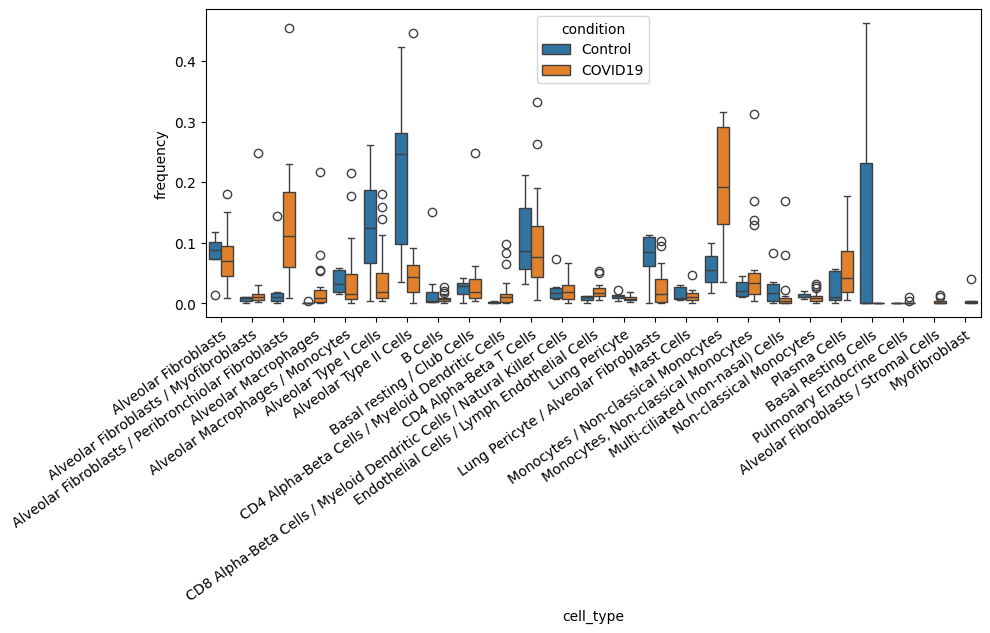

In [31]:
#Plot the frequency of cell types per sample
import matplotlib.pyplot as plt

plt.figure(figsize= (10, 4))

ax = sns.boxplot(data= cell_type_counts, x= "cell_type", y= "frequency", hue= "condition")
plt.xticks(rotation = 35, rotation_mode= "anchor", ha= "right")

plt.show()

In [6]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [49]:
#Calculating statistics for cell type representation

all_cell_types = cell_type_counts["cell_type"].unique()

results = []

for cells in all_cell_types:
    cell_df = cell_type_counts[cell_type_counts["cell_type"] == cells]

    control_props = cell_df.loc[
        cell_df["condition"] == "Control", "frequency"
    ]

    covid_props = cell_df.loc[
        cell_df["condition"] == "COVID19", "frequency"
    ]

    if len(control_props) > 0 and len (covid_props) > 0:
        stat, p_val = mannwhitneyu(control_props, covid_props, alternative= "two-sided")

        results.append(
            {
                "Cell_Type" : cells,
                "Control_Mean_Frequency" : control_props.mean(),
                "COVID_Mean_Frequency" : covid_props.mean(),
                "Control_Donors_Count" : len(control_props),
                "COVID_Donors_Count" : len(covid_props),
                "U_Statistic" : stat,
                "P_Value" : p_val,

            }
        )

results_df = pd.DataFrame(results)

reject, p_adjusted, _, _ = multipletests(
    results_df["P_Value"], alpha=0.05, method= "fdr_bh"
    )

results_df["FDR_Adjusted_P"] = p_adjusted 

results_df = results_df.sort_values(by= "FDR_Adjusted_P")

print(results_df)


                                            Cell_Type  Control_Mean_Frequency  \
16                Monocytes / Non-classical Monocytes                0.056907   
3                                Alveolar Macrophages                0.001182   
6                              Alveolar Type II Cells                0.208817   
2   Alveolar Fibroblasts / Peribronchiolar Fibrobl...                0.027706   
9      CD4 Alpha-Beta Cells / Myeloid Dendritic Cells                0.001757   
12        Endothelial Cells / Lymph Endothelial Cells                0.008314   
14               Lung Pericyte / Alveolar Fibroblasts                0.077317   
5                               Alveolar Type I Cells                0.128157   
20                                       Plasma Cells                0.026248   
13                                      Lung Pericyte                0.011741   
1               Alveolar Fibroblasts / Myofibroblasts                0.007328   
4                    Alveola

In [50]:
results_df

,Cell_Type,Control_Mean_Frequency,COVID_Mean_Frequency,Control_Donors_Count,COVID_Donors_Count,U_Statistic,P_Value,FDR_Adjusted_P
16,Monocytes / Non-classical Monocytes,0.056907,0.197215,7,20,10.0,0.000297,0.006838
3,Alveolar Macrophages,0.001182,0.027661,6,19,9.0,0.001016,0.011688
6,Alveolar Type II Cells,0.208817,0.060391,7,20,120.0,0.004146,0.019073
2,Alveolar Fibroblasts / Peribronchiolar Fibrobl...,0.027706,0.127303,7,20,18.0,0.002651,0.019073
9,CD4 Alpha-Beta Cells / Myeloid Dendritic Cells,0.001757,0.020148,7,19,18.0,0.003579,0.019073
12,Endothelial Cells / Lymph Endothelial Cells,0.008314,0.020857,7,20,22.0,0.006297,0.024139
14,Lung Pericyte / Alveolar Fibroblasts,0.077317,0.026551,7,20,112.0,0.019013,0.062471
5,Alveolar Type I Cells,0.128157,0.045725,7,20,106.0,0.047798,0.137419
20,Plasma Cells,0.026248,0.059253,7,20,37.0,0.071572,0.182906
13,Lung Pericyte,0.011741,0.008704,7,20,97.0,0.145482,0.334608


The proportional representation of each cell type was compared between the two conditions, adjusting for multiple simultaneous testing errors at the single-cell level using the Benjamini-Hochberg correction.  

Significant decreases in cell number were observed for alveolar type I (p = 0.04), alveolar type II (p = 0.004) and lung pericytes / alveolar fibroblasts (p = 0.01) cells in COVID-19 conditions compared to healthy controls. In contrast, monocytes / non-classical monocytes (p = 0.0002), alveolar macrophages (p = 0.001), peribronchiolar fibroblasts (p = 0.002), CD4 positive alpha-beta T cells (p = 0.003) and endothelial cells (p = 0.006) were notably increased in COVID-19 conditions compared to healthy controls. 

To further investigate the decrease in AT1 and AT2 cell types in COVID-19 relative to healthy conditions, differential gene expression was performed on these cell types via implementation of SCVI generative deep learning models. 

**Single Cell Differential Gene Expression with SCVI Generative Models**  

In [9]:
#Create an SCVI normalised expression layer in the adata_combined object from the integration model
adata_combined.layers["scvi_normalised"] = model_integrated.get_normalized_expression(library_size=1e4)

AT2 cell differential expression was interrogated first owing to the significance of the reduction in COVID-19 compared to healthy controls. 

In [ ]:
#Compare AT2 cell differential expression between conditions
scvi_at2_de = model_integrated.differential_expression(
     idx1= [(adata_combined.obs["cell_type"] =="Alveolar Type II Cells").values & (adata_combined.obs.condition == "COVID19")],
     idx2= [(adata_combined.obs["cell_type"] =="Alveolar Type II Cells").values & (adata_combined.obs.condition == "Control")],
     mode= "vanilla",
)

In [ ]:
#View the AT2 Differential Expression
scvi_at2_de

In [15]:
scvi_at2_de["lfc_true_direction"] = np.log2(
    (scvi_at2_de["scale1"] + 1e-9) / (scvi_at2_de["scale2"] + 1e-9)
)

# 2. Filter using the corrected direction
significant_hits = scvi_at2_de[scvi_at2_de["bayes_factor"] > 3]

# Now > 0.3 correctly indicates higher expression in COVID-19
scvi_at2_de_upregulated = significant_hits[significant_hits["lfc_true_direction"] > 0.5]
scvi_at2_de_downregulated = significant_hits[significant_hits["lfc_true_direction"] < -0.5]

print(f"True Upregulated in COVID-19 (Higher in COVID): {len(scvi_at2_de_upregulated)} genes")
print(f"True Downregulated in COVID-19 (Lower in COVID): {len(scvi_at2_de_downregulated)} genes")

True Upregulated in COVID-19 (Higher in COVID): 134 genes
True Downregulated in COVID-19 (Lower in COVID): 0 genes


In [ ]:
scvi_at2_de_upregulated.head(50)

In [17]:
#Create AT2 cell subset
at2_subset = adata_combined[(adata_combined.obs["cell_type"] == "Alveolar Type II Cells").values].copy()

In [38]:
#create list of genes to show
at2_genes_to_show = scvi_at2_de_upregulated.index[:50]

**AT2 Differential Gene Expression Control vs COVID-19**

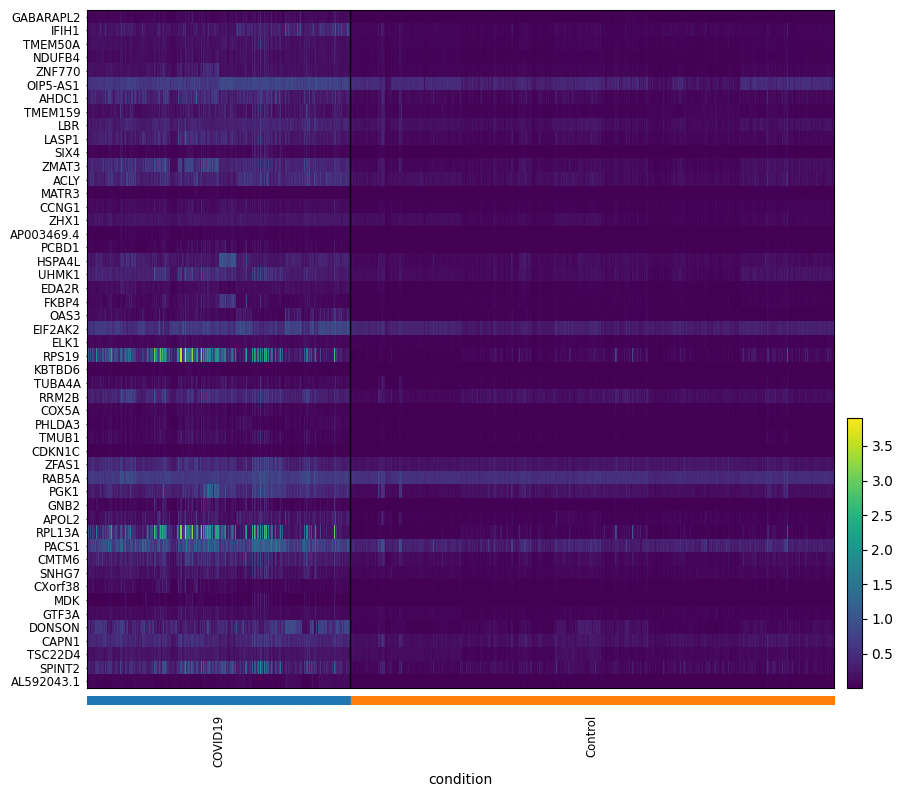

In [39]:
sc.pl.heatmap(at2_subset, at2_genes_to_show, groupby="condition", swap_axes=True, layer= "scvi_normalised", log= True)

The top 50 significant differentially expressed genes in AT2 single cells depict a general trend of up-regulation under COVID-19 conditions relative to healthy controls. 134 differentially expressed genes were up-regulated in COVID-19 conditions compared to healthy controls. No genes were down-regulated in COVID-19. Multiple genes including PHILDA3, EDA2R, CCNG1, ZMAT3 and RRM2B are components of the P53 signalling pathway and signal cellular stress. LBR and MATR3 are involved in nuclear envelope architecture whereas GABARAPL2 and HSPA4L relate to protein homeostasis as autophagosome and heat shock protein chaperones respectively. RSP19 is a core structural component of ribosomes. The up-regulation of these proteins may indicate an immune response to undergo apoptosis in these cells under COVID-19 conditions.   

In [ ]:
at2_genes_to_show

**Pseudobulk Analysis of AT2 Differential Gene Expression**

Prior to pseudobulk analysis, confirm the read counts are raw counts, not normalised counts.

In [21]:
#Confirm counts are raw counts
at2_counts = at2_subset.layers["counts"]

if not isinstance(at2_counts, np.ndarray):
    at2_counts = at2_counts.toarray()
    print(at2_counts.dtype, at2_counts.min(), at2_counts.max())

float32 0.0 1922.0


Aggregating the raw sum counts per donor was performed to populate the data layer.

In [ ]:
#Building the numerical array of counts first, then the dataframe will be populated 

at2_donor_ids = at2_subset.obs["Sample"].astype(str).values
at2_unique_donors = at2_subset.obs["Sample"].astype(str).unique()


at2_pseudobulk_rows = []

for donor in at2_unique_donors:
    at2_mask = (at2_donor_ids == donor)
    print(donor, at2_mask.sum())
    at2_row_sum = np.asarray(at2_counts[at2_mask].sum(axis=0)).flatten()
    at2_pseudobulk_rows.append(at2_row_sum)

at2_pseudobulk_counts = pd.DataFrame(
    at2_pseudobulk_rows,
    index=at2_unique_donors,
    columns= at2_subset.var_names
).astype(np.int64)


print(at2_pseudobulk_counts.shape)
print(at2_pseudobulk_counts.sum(axis=1))

Building the donor-level metadata

In [ ]:
#Build donor-level metadata
at2_donor_metadata = (
    at2_subset.obs[["Sample", "condition"]].drop_duplicates().set_index("Sample").loc[at2_unique_donors]
)
print(at2_donor_metadata["condition"].value_counts())

A minimum cell threshold was applied to reduce the noise in differential expression analysis and exclude donors with low coverage i.e. < 20 cells.

In [ ]:
at2_cell_counts_per_donor = at2_subset.obs["Sample"].astype(str).value_counts()
print(at2_cell_counts_per_donor)



AT2_MIN_CELLS = 20
at2_valid_donors = at2_cell_counts_per_donor[at2_cell_counts_per_donor > AT2_MIN_CELLS].index.tolist()

at2_pseudobulk_counts = at2_pseudobulk_counts[at2_pseudobulk_counts.index.isin(at2_valid_donors)]
at2_donor_metadata = at2_donor_metadata.loc[at2_donor_metadata.index.isin(at2_valid_donors)]

print(at2_pseudobulk_counts.shape)
print(at2_donor_metadata["condition"].value_counts())

**Pseudobulk: Implementing Pydeseq2**



Preparing input formats for Pydeseq2. 

In [25]:
#Ensure raw counts are as integers and dataframes are in the cell x gene orientation
at2_pseudobulk_counts = at2_pseudobulk_counts.astype(int)

#Drop genes with all-zero counts across donors to prevent Pydeseq2 errors
at2_pseudobulk_counts = at2_pseudobulk_counts.loc[:, at2_pseudobulk_counts.sum(axis=0) > 0]

print(at2_pseudobulk_counts.shape)

(23, 19590)


The dataset is in the right dimensions: donor x genes (23 donors and 19590 genes).

**Building the  AT2 Pseudobulk Differential Expression Dataset**

In [26]:
#Build the dataset

at2_dds = DeseqDataSet(
    counts= at2_pseudobulk_counts,
    metadata= at2_donor_metadata,
    design_factors= "condition",
    refit_cooks=True
)

C:\Users\Ashhazz\AppData\Local\Temp\ipykernel_24760\395500400.py:3: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  at2_dds = DeseqDataSet(


**Run the AT2 DDS Pipeline** 

In [ ]:
#Run the pipeline
at2_dds.deseq2()

Extracting the Statistics for Comparison

In [ ]:
at2_stat_res = DeseqStats(at2_dds, contrast= ["condition", "COVID19", "Control"])
at2_stat_res.summary()


at2_results_df = at2_stat_res.results_df 
at2_results_df = at2_results_df.sort_values("padj")
at2_results_df.head(20)

Filtering the AT2 Pseudobulk Differential Gene Expression List of Statistical Significance

In [ ]:
#Filtereing pydeseq2 results
at2_sig_genes = at2_results_df[(at2_results_df["padj"] < 0.05) & (abs(at2_results_df["log2FoldChange"]) > 0.5)]
at2_sig_genes = at2_sig_genes.sort_values("log2FoldChange", ascending=False)
at2_sig_genes

In [ ]:
at2_sig_genes.loc["ZMAT3"]

To investigate the most highly differentially expressed genes in the pseudobulk list, Gene Set Enrichment Analysis suing the Hallmark gene set was performed. 

In [20]:
#Checking to see if SCVI DE genes are present in Pseudobulk DE genes
at2_single_cell_de = pd.DataFrame(scvi_at2_de_upregulated)

In [31]:
at2_single_cell_de["pseudobulk represented"] = at2_single_cell_de.index.isin(at2_sig_genes.index)

In [ ]:
at2_single_cell_de

In [33]:
at2_single_cell_de_pseudo = at2_single_cell_de[at2_single_cell_de["pseudobulk represented"] == True]

In [ ]:
at2_single_cell_de_pseudo.lfc_true_direction.sort_values(ascending=False)
at2_single_cell_de_pseudo[:30]

Ranking was performed using the Wald statistic to factor in statistical power and effect magnitude direction.

In [ ]:
#Create rankings
at2_ranking = (
    at2_results_df["stat"].replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
)

print("Number of genes:", len(at2_ranking))
print(at2_ranking.head(10))
print(at2_ranking.tail(10))

Perform GSEA pre-rank


In [87]:
at2_gsea_hallmark = gp.prerank(
    rnk= at2_ranking,
    gene_sets= "MSigDB_Hallmark_2020",
    permutation_num=1000,
    seed=42,
    outdir=None
)

2026-09-08 17:40:16,405 [WARNING] Duplicated values found in preranked stats: 5.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [88]:
at2_gsea_hallmark.res2d.sort_values("FDR q-val")[["Term", "NES", "NOM p-val", "FDR q-val"]].head(10)

,Term,NES,NOM p-val,FDR q-val
0,mTORC1 Signaling,2.280246,0.000000,0.000000
1,Interferon Alpha Response,2.254218,0.000000,0.000000
2,Myc Targets V1,2.179700,0.000000,0.000000
5,Unfolded Protein Response,1.960320,0.000000,0.000170
4,p53 Pathway,2.018059,0.000000,0.000204
3,Oxidative Phosphorylation,2.124806,0.000000,0.000255
6,Interferon Gamma Response,1.944915,0.000000,0.000292
8,Pperoxisome,1.843219,0.000000,0.000568
7,Reactive Oxygen Species Pathway,1.858346,0.001333,0.000639
10,Cholesterol Homeostasis,1.801502,0.001267,0.000836


The top hallmark gene sets from the gsea pre-rank assessment belonged to mTORC1 signalling, Interferon Alpha Response, Myc Targets V1, Unfolded Protein Response and the p53 Pathway as well as other pathways involved in oxidative stress repsonses. These pathways highlight a trend of cellular immune responses, survival signalling, programmed cell death and oxidative and metabolic stress. These pathways were all upregulated in COVID-19 compared to control conditions. 

To identify genes implicated in these pathways, the significantly differentially expressed genes were separated by direction of their effect size i.e. upregulated in COVID-19 conditions (positive) and upregulated in Control conditions (negative). Over Representation Analysis (ORA) was subsequently performed on up and down regulated gene sets. 

In [89]:
at2_upregulated = at2_sig_genes[at2_sig_genes["log2FoldChange"] > 0.5].index.tolist()

In [91]:
at2_downregulated = at2_sig_genes[at2_sig_genes["log2FoldChange"] < -0.5].index.to_list()

**AT2 Cells Over Representation Analysis** 

In [93]:
#Interrogate Upregulated genes
at2_upregulated_enr = gp.enrichr(
    gene_list= at2_upregulated,
    gene_sets= ["KEGG_2021_Human", "GO_Biological_Process_2021"],
    organism= "human",
    outdir= None,
    background= at2_results_df.index.tolist()
    
)

In [94]:
#View the ORA results
at2_upregulated_enr.res2d

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,2.064318e-62,6.337456e-60,0,0,23.878989,3391.663618,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
1,KEGG_2021_Human,Coronavirus disease,1.479517e-49,2.271059e-47,0,0,11.441698,1286.446783,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
2,KEGG_2021_Human,Protein processing in endoplasmic reticulum,1.287587e-14,1.317630e-12,0,0,4.674325,149.500909,ERO1A;HSP90AB1;ATF6B;PRKCSH;HSPA4L;RPN1;HSP90B...
3,KEGG_2021_Human,Antigen processing and presentation,3.502201e-13,2.687939e-11,0,0,8.969649,257.251447,HSP90AB1;CTSS;B2M;HLA-DPA1;PDIA3;HSPA8;HSP90AA...
4,KEGG_2021_Human,Prion disease,1.288354e-10,7.910491e-09,0,0,3.178607,72.384785,NDUFA13;COX4I1;COX6A1;COX7C;PSMD8;TUBB6;CSNK2A...
...,...,...,...,...,...,...,...,...,...
4637,GO_Biological_Process_2021,regulation of generation of precursor metaboli...,9.797249e-01,9.806297e-01,0,0,0.251101,0.005143,NDC1
4638,GO_Biological_Process_2021,regulation of neurogenesis (GO:0050767),9.842813e-01,9.849630e-01,0,0,0.235368,0.003729,B2M
4639,GO_Biological_Process_2021,monocarboxylic acid biosynthetic process (GO:0...,9.905532e-01,9.910105e-01,0,0,0.209146,0.001985,ACLY
4640,GO_Biological_Process_2021,double-strand break repair via nonhomologous e...,9.913219e-01,9.915507e-01,0,0,0.205332,0.001790,POLQ


Interestingly, the ORA results illustrate Corona Virus disease response associated genes in the top 2 hits (p = 2.27e-47) and enrichment of genes associated with ribosomal construction pathways (p = 6.33e-60). These top two processes share redundancy in their enriched genes upregulated in COVID-19 conditions in AT2 cells. Additionally, the remaining three of the five hits relate to protein processing, antigen presentation and prion disease, commensurate with a cellular immune response.  

In [95]:
#Interrogate downregulated genes
at2_downregulated_enr = gp.enrichr(
    gene_list= at2_downregulated,
    gene_sets= ["KEGG_2021_Human", "GO_Biological_Process_2021"],
    organism= "human",
    outdir= None,
    background= at2_results_df.index.tolist()
)
    

In [96]:
#View the ORA downregulated results
at2_downregulated_enr.res2d

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Insulin resistance,0.000040,0.010446,0,0,4.003884,40.589328,PRKCE;NR1H2;PRKAG2;PRKAB1;NFKB1;MAPK10;RPS6KA3...
1,KEGG_2021_Human,Circadian rhythm,0.000133,0.017557,0,0,7.510692,67.033506,PER2;FBXW11;CUL1;CRY1;PRKAG2;RORA;PRKAB1
2,KEGG_2021_Human,Arrhythmogenic right ventricular cardiomyopathy,0.001264,0.097782,0,0,3.796343,25.334530,TCF7L1;CACNB4;LAMA1;TCF7;LMNA;CACNA2D3;CACNA2D...
3,KEGG_2021_Human,Adipocytokine signaling pathway,0.002130,0.097782,0,0,3.853185,23.702640,MAPK10;SOCS3;MAPK8;PRKAG2;PRKCQ;CD36;PRKAB1;NFKB1
4,KEGG_2021_Human,Oxytocin signaling pathway,0.002287,0.097782,0,0,2.675362,16.267161,MAP2K1;NPR1;CACNA2D3;ITPR1;CACNA2D2;PRKAG2;FOS...
...,...,...,...,...,...,...,...,...,...
2864,GO_Biological_Process_2021,mRNA processing (GO:0006397),0.997987,0.998966,0,0,0.323125,0.000651,SFPQ;PCF11;RBM4B;SRSF7
2865,GO_Biological_Process_2021,negative regulation of cytokine production (GO...,0.997989,0.998966,0,0,0.158314,0.000319,RPS6KA5
2866,GO_Biological_Process_2021,gene expression (GO:0010467),0.998199,0.998966,0,0,0.350899,0.000633,THRB;NUP98;SRSF7;GSPT1;ABCF1
2867,GO_Biological_Process_2021,rRNA metabolic process (GO:0016072),0.998786,0.999169,0,0,0.146272,0.000178,MAPT


In [100]:
at2_downregulated_enr.res2d["Genes"].iloc[0]

'PRKCE;NR1H2;PRKAG2;PRKAB1;NFKB1;MAPK10;RPS6KA3;SOCS3;MAPK8;TBC1D4;PRKCQ;CD36;SLC27A3;OGT'

The top 2 significantly downregulated processes were insulin resistance (p = 0.010) and circadian rhythm (p = 0.017). The enriched genes for the insulin resistance processes included members of the protein kinase C family, necrosis factor kappa Beta family, MAP Kinase signalling pathway family, TBC1D4 of the GLUT4 transporter regulation of insulin and OGT (O-GlcNAc) involved in insulin signalling. Lipid metabolism genes NR1H2, CD36 and SLC27A3 also featured in association with insulin resistance. Genes PER2, FBXW11, CUL1, CRY1, PRKAG2, RORA and PRKAB1 were all associated with circadian rhythm.

**Reactome Analysis**

Reactome analysis was performed to obtained more granualr detail on the specific cellular mechanisms enriched within the significant differentially expressed gene list.  

In [30]:
#Running reactome analysis on the AT2 signifcant genes list

at2_reactome_ora = gp.enrichr(
    gene_list= at2_sig_genes.index.tolist(),
    gene_sets= "Reactome_2022",
    organism= "human",
    background= at2_results_df.index.tolist(),
    outdir=None

)

at2_reactome_ora.res2d.head(20)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,Eukaryotic Translation Elongation R-HSA-156842,3.698544e-62,5.825207e-59,0,0,72.429775,10245.360951,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
1,Reactome_2022,Peptide Chain Elongation R-HSA-156902,1.644810e-59,1.295288e-56,0,0,69.553841,9414.452912,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
2,Reactome_2022,Selenocysteine Synthesis R-HSA-2408557,7.024276e-57,3.687745e-54,0,0,50.575784,6539.346582,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
3,Reactome_2022,Eukaryotic Translation Termination R-HSA-72764,4.496756e-56,1.770598e-53,0,0,46.358438,5907.984607,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
4,Reactome_2022,SRP-dependent Cotranslational Protein Targetin...,1.877044e-54,5.912688e-52,0,0,26.507623,3279.255284,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
5,Reactome_2022,Response Of EIF2AK4 (GCN2) To Amino Acid Defic...,4.039108e-54,1.060266e-51,0,0,33.615475,4132.806486,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
6,Reactome_2022,Selenoamino Acid Metabolism R-HSA-2408522,7.972048e-54,1.793711e-51,0,0,29.335538,3586.670088,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
7,Reactome_2022,Nonsense Mediated Decay (NMD) Independent Of E...,5.606822e-53,1.103843e-50,0,0,36.570089,4399.858084,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
8,Reactome_2022,Viral mRNA Translation R-HSA-192823,7.573438e-53,1.325352e-50,0,0,38.638329,4637.077196,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...
9,Reactome_2022,Formation Of A Pool Of Free 40S Subunits R-HSA...,1.062699e-47,1.673752e-45,0,0,24.576581,2658.219867,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...


The top 20 reactome hits converge on the ribosomal bioprocesses indicated in the ORA enrichment scores. The list is heavily dominated by protein synthesis and structural ribosomal unit processing which show reduncdancy in enriched genes including RPL4, RPL5, RPL30, RPL3, RPL32, RPL31, RPL34 and RPLP1 to name a few.

Reactome Pre-reank was performed to view the highest ranked reactome hits. 

In [ ]:
#Running reactome hallmark ranking
at2_reactome_gsea = gp.prerank(
    rnk= at2_ranking,
    gene_sets= "Reactome_2022",
    permutation_num= 5000,
    min_size= 15,
    max_size= 500,
    seed=42,
    outdir=None
)

Ranking the AT2 Reactome results by expression level 

In [33]:
at2_reactome_results = at2_reactome_gsea.res2d.copy()

at2_reactome_results[
    ["Term", "NES", "NOM p-val", "FDR q-val"]
].head(20)

,Term,NES,NOM p-val,FDR q-val
0,Eukaryotic Translation Elongation R-HSA-156842,3.291909,0.0,0.0
1,Peptide Chain Elongation R-HSA-156902,3.283353,0.0,0.0
2,SRP-dependent Cotranslational Protein Targetin...,3.248776,0.0,0.0
3,Viral mRNA Translation R-HSA-192823,3.233536,0.0,0.0
4,Response Of EIF2AK4 (GCN2) To Amino Acid Defic...,3.227961,0.0,0.0
5,Selenocysteine Synthesis R-HSA-2408557,3.218916,0.0,0.0
6,Eukaryotic Translation Termination R-HSA-72764,3.210193,0.0,0.0
7,Nonsense Mediated Decay (NMD) Independent Of E...,3.208918,0.0,0.0
8,Selenoamino Acid Metabolism R-HSA-2408522,3.183585,0.0,0.0
9,Formation Of A Pool Of Free 40S Subunits R-HSA...,3.171082,0.0,0.0


Sort the Reactome pre-rank results by FDR q-val

In [36]:
at2_reactome_results =at2_reactome_results.sort_values("FDR q-val")

at2_reactome_results[
    ["Term", "NES", "NOM p-val", "FDR q-val"]
].head(20)

,Term,NES,NOM p-val,FDR q-val
6,Eukaryotic Translation Termination R-HSA-72764,3.210193,0.0,0.0
13,Cap-dependent Translation Initiation R-HSA-72737,3.082041,0.0,0.0
36,EPH-Ephrin Signaling R-HSA-2682334,2.156031,0.0,0.0
35,Calnexin/calreticulin Cycle R-HSA-901042,2.160804,0.0,0.0
34,Nervous System Development R-HSA-9675108,2.168268,0.0,0.0
33,Regulation Of Actin Dynamics For Phagocytic Cu...,2.169455,0.0,0.0
32,Axon Guidance R-HSA-422475,2.219043,0.0,0.0
31,SARS-CoV-2 Infection R-HSA-9694516,2.231842,0.0,0.0
30,"Antigen Presentation: Folding, Assembly, Pepti...",2.232180,0.0,0.0
9,Formation Of A Pool Of Free 40S Subunits R-HSA...,3.171082,0.0,0.0


The Reactome pre-rank results were sorted by enriched (ascending = False) and depleted (ascending= True) to identify processes enriched and depleted under COVID-19 conditions respectively.

In [37]:
at2_reactome_res_enriched =at2_reactome_results[
    at2_reactome_results["FDR q-val"] < 0.05].sort_values("NES", ascending=False)[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(20)

In [38]:
#View the enriched results
at2_reactome_res_enriched

,Term,NES,NOM p-val,FDR q-val
0,Eukaryotic Translation Elongation R-HSA-156842,3.291909,0.0,0.0
1,Peptide Chain Elongation R-HSA-156902,3.283353,0.0,0.0
2,SRP-dependent Cotranslational Protein Targetin...,3.248776,0.0,0.0
3,Viral mRNA Translation R-HSA-192823,3.233536,0.0,0.0
4,Response Of EIF2AK4 (GCN2) To Amino Acid Defic...,3.227961,0.0,0.0
5,Selenocysteine Synthesis R-HSA-2408557,3.218916,0.0,0.0
6,Eukaryotic Translation Termination R-HSA-72764,3.210193,0.0,0.0
7,Nonsense Mediated Decay (NMD) Independent Of E...,3.208918,0.0,0.0
8,Selenoamino Acid Metabolism R-HSA-2408522,3.183585,0.0,0.0
9,Formation Of A Pool Of Free 40S Subunits R-HSA...,3.171082,0.0,0.0


The top 20 ranked enriched processes in COVID-19 conditions are dominated by those pertaining to protein synthesis, ribosome assembly, RNA processing, cellular immune response to infection and starvation.  

In [39]:
at2_reactome_res_depleted =at2_reactome_results[
    at2_reactome_results["FDR q-val"] < 0.05].sort_values("NES", ascending=True)[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(20)

In [40]:
#View the depleted reactome processes in COVID-19 conditions
at2_reactome_res_depleted

,Term,NES,NOM p-val,FDR q-val
296,AURKA Activation By TPX2 R-HSA-8854518,1.548816,0.007323,0.049451
295,Metabolism Of Polyamines R-HSA-351202,1.549432,0.012966,0.049344
294,Nucleotide Salvage R-HSA-8956321,1.549963,0.026995,0.049230
293,Interleukin-12 Signaling R-HSA-9020591,1.550949,0.015023,0.048942
292,Regulation Of RAS By GAPs R-HSA-5658442,1.553683,0.012964,0.047905
291,Apoptotic Factor-Mediated Response R-HSA-111471,1.553733,0.025424,0.048058
290,Transcription Of E2F Targets Under Negative Co...,1.554058,0.025837,0.048090
289,Transferrin Endocytosis And Recycling R-HSA-91...,1.562371,0.020897,0.044482
288,Cross-presentation Of Soluble Exogenous Antige...,1.563958,0.013658,0.043955
286,FOXO-mediated Transcription R-HSA-9614085,1.568204,0.010003,0.042320


The top ranked processes depeleted under COVID-19 conditions pertain to cellular proliferation, DNA/RNA replication, cellualr defence, immune signalling, apoptosis pathways, metabolic pathway signalling and protein folding. Interestingly, cellular innate and adaptive immunity to SARs-CoV-2 infection is explicitly within the top 20 ranks.  

The reactome results were separated into upregulated and downregulated via normalised enriched score (NES) to identify pathways up and downregulated in COVID-19 conditions.  

In [41]:
at2_reactome_sig = at2_reactome_results[
    at2_reactome_results["FDR q-val"] < 0.05
].copy()

In [ ]:
#Create the up and down regulated reactome lists
at2_reactome_up = at2_reactome_sig[
    at2_reactome_sig["NES"] > 0
].sort_values("NES", ascending=False)

at2_reactome_down = at2_reactome_sig[
    at2_reactome_sig["NES"] < 0
].sort_values("NES", ascending=True)

In [ ]:
at2_reactome_up[
    ["Term", "NES", "FDR q-val", "Lead_genes"]
].head(30)

While many of the top 30 pathways relate to ribosome assembly and functioning, protein synthesis via translation and host cell immune response, viral mRNA translation, influenze and viral transfection and SARs-Cov-2-host interaction pathways are also represented. Redundancy of ribosomal subunit gene enrichment exists for all of these pathways but HLA-C and B2M genes stand out for SARs-CoV-2-host interactions.  

In [44]:
at2_reactome_down[
    ["Term", "NES", "FDR q-val", "Lead_genes"]
].head(30)

,Term,NES,FDR q-val,Lead_genes


No significantly down regulated pathways were identified.  

**Interrogation of P53 signalling pathway genes distribution in single AT2 cells**

*ZMAT3* and *PHLDA3* are key components of canonical P53 signalling pathways. They are downstream targets of P53 and transcriptionally activated via direct binding of P53 to their promoters. ZMAT3, an RNA-binding protein positively regulates p53 expression through exon-exclusion and hence preclusion of P53 suppressor activation (Bieging-Rolett *et al*, 2021). PHLDA3 activation results in suppression of AKT signalling in AT2 cells, alleviating inhibition of AT2 progenitor transdifferentiation to AT1 cells (Ohnishi *et al*, 2024)  Considering the magnitude of downregulation of *ZMAT3* (Bayes Factor= 4.14, LFC mean = -2.55) and *PHLDA3* (Bayes Factor= 3.63 and LFC mean = -3.43)in differential expression at the single cell level and the conservation of P53 signalling pathway gene enrichment in pseudobulk and Over Represent Analysis, *ZMAT3* and *PHLDA3* distribution was interrogated at the single cell level. 

In [50]:
at2_subset.obs["condition"] = at2_subset.obs["condition"].astype("category")

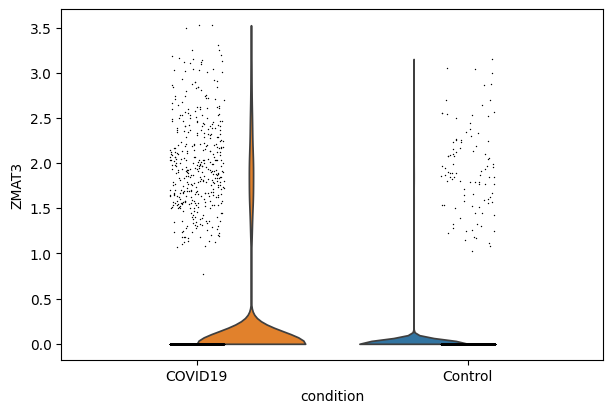

In [105]:
#Examining the ZMAT3 expression level distribution in single AT2 cells

sc.pl.violin(at2_subset[at2_subset.obs["cell_type"] == "Alveolar Type II Cells"], "ZMAT3", groupby= "condition")

Two subsets of *ZMAT3* expression exist in the AT2 cell population in both COVID-19 and control conditions. The majority of cells have no *ZMAT3* expression in either condition, though the is a greater preponderance of cells in COVID-19 conditions. In COVID-19 conditions, the smaller subset of AT2 cells demonstrate a diffuse pattern of expression with majority of cells expressing *ZMAT3* between 1 and 2.5 and fewer cells expressing above 2.5 to 3.5 fold levels. In contrast, the *ZMAT3* expression in control AT2 cells within smaller subpopulation is approximately uniform in cell density (illustrated by the straight vertical line with no bulge) and *ZMAT3* expression ranges between 1 and approximately 3-fold.  

**Interrogation of ZMAT3 Gene Expression and Distribution in Donors**

In [ ]:
#get DESeq2's size-factor-normalised counts (not raw) so donor comparisons are library sized corrected.
at2_normalised_counts = at2_dds.layers["normed_counts"] # donors x genes, same index / columns as pesudobulk counts
at2_normalised_counts = pd.DataFrame(at2_normalised_counts, index= at2_pseudobulk_counts.index, columns= at2_pseudobulk_counts.columns)

zmat3_normalised =at2_normalised_counts["ZMAT3"]

#Reference point: mean zmat3 expression in Control donors
zmat3_control_mean = zmat3_normalised[at2_donor_metadata["condition"] == "Control"].mean()

#Build the per donor comparison dataframe
zmat3_by_donor = pd.DataFrame(
    {
        "Sample" : at2_pseudobulk_counts.index,
        "condition" : at2_donor_metadata["condition"].values,
        "n_cells" : at2_cell_counts_per_donor.reindex(at2_pseudobulk_counts.index).values,
        "zmat3_normalised_counts" : zmat3_normalised.values,
    })

zmat3_by_donor["log2FC_vs_control_mean"] = np.log2(
  (zmat3_by_donor["zmat3_normalised_counts"] + 1) / (zmat3_control_mean + 1)
 )

zmat3_by_donor = zmat3_by_donor.sort_values("n_cells")
zmat3_by_donor

Pearson r=-0.593, p=0.003


<Axes: xlabel='n_cells', ylabel='log2FC_vs_control_mean'>

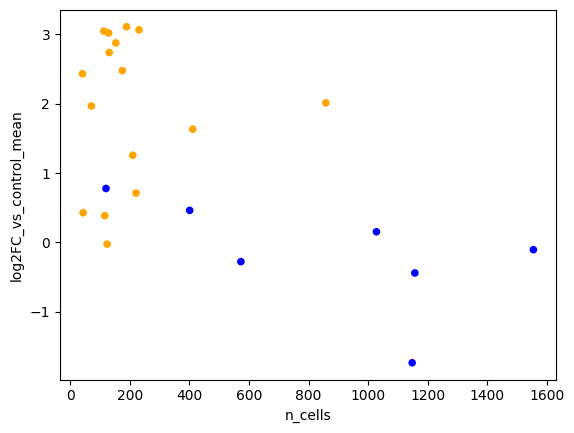

In [ ]:
#Determine if any correlation exists between donor cell number and ZMAT3 expression level
r, p = stats.pearsonr(zmat3_by_donor["n_cells"], zmat3_by_donor["log2FC_vs_control_mean"])
print(f"Pearson r={r:.3f}, p={p:.3f}")

zmat3_by_donor.plot.scatter(x="n_cells", y= "log2FC_vs_control_mean", c= zmat3_by_donor["condition"].map({"COVID19": "orange", "Control" : "blue"}))

Analysis of the *ZMAT3* expression in AT2 cells between donors revealed that *ZMAT3* expression is not independent of cell number (Pearson Correlation Coefficient, r= 0.593, p= 0.003), suggesting a moderate positive correlation in *ZMAT3* expression as donor cell numbers increase. However control donors appear, visually, to be decreasing in *ZMAT3* expression level as donor cell numbers increase. 

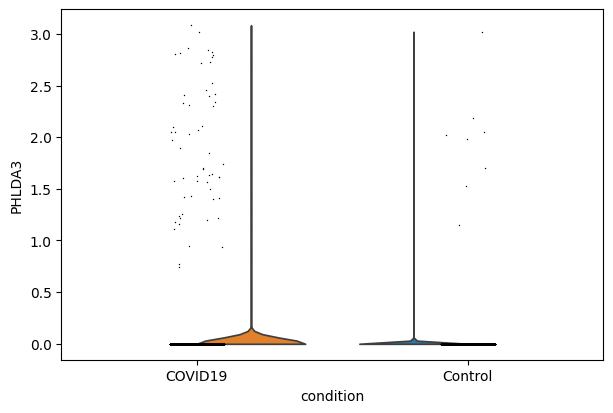

In [108]:
#Examining the PHLDA3 expression level distribution in single AT2 cells

sc.pl.violin(at2_subset[at2_subset.obs["cell_type"] == "Alveolar Type II Cells"], "PHLDA3", groupby= "condition")

Similar to *ZMAT3* expression in AT2 cells, a subset of *PHLDA3* expressing cells exist within a majority of *PHLDA3* non-expressing cells in both COVID-19 and control conditions, with the former possessing greater numbers of expressing and non-expressing cells than the latter. In COVID-19 conditions, the *PHLDA3* expression ranges between 0.75 to over 3 while in control cells expression is narrower between 1 and 2.2 for the main expressing cluster and 1 possible outlier expressing above 3.  

**Interrogating PHLDA3 Expression and Distirbution between Donors**

In [ ]:
phlda3_normalised =at2_normalised_counts["PHLDA3"]

#Reference point: mean phlda3 expression in Control donors
phlda3_control_mean = phlda3_normalised[at2_donor_metadata["condition"] == "Control"].mean()

#Build the per donor comparison dataframe
phlda3_by_donor = pd.DataFrame(
    {
        "Sample" : at2_pseudobulk_counts.index,
        "condition" : at2_donor_metadata["condition"].values,
        "n_cells" : at2_cell_counts_per_donor.reindex(at2_pseudobulk_counts.index).values,
        "phlda3_normalised_counts" : phlda3_normalised.values,
    })

phlda3_by_donor["log2FC_vs_control_mean"] = np.log2(
  (phlda3_by_donor["phlda3_normalised_counts"] + 1) / (phlda3_control_mean + 1)
 )

phlda3_by_donor = phlda3_by_donor.sort_values("n_cells")
phlda3_by_donor

Pearson r=-0.266, p=0.220


<Axes: xlabel='n_cells', ylabel='log2FC_vs_control_mean'>

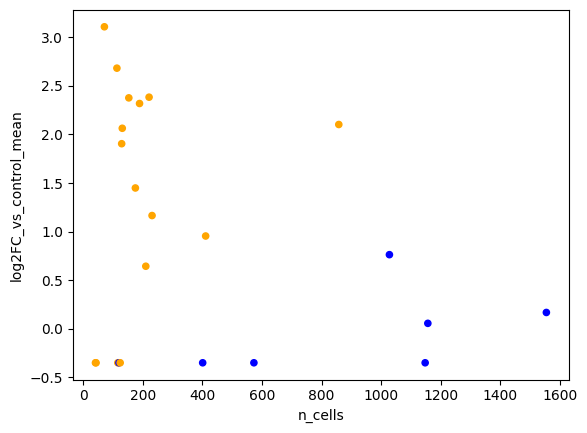

In [ ]:
#Determine if any correlation exists between donor cell number and PHLDA3 expression level
r, p = stats.pearsonr(phlda3_by_donor["n_cells"], phlda3_by_donor["log2FC_vs_control_mean"])
print(f"Pearson r={r:.3f}, p={p:.3f}")

phlda3_by_donor.plot.scatter(x="n_cells", y= "log2FC_vs_control_mean", c= phlda3_by_donor["condition"].map({"COVID19": "orange", "Control" : "blue"}))

A weak, insignificant, negative correlation between donor cell number and *PHLDA3* expression exists. A clear disparity in *PHLDA3* expression is evident between control donors as a subset (n=3) do not express *PHLDA3* regardless of increasing cell number are distinct from *PHLDA3* expressing donors and have identical expression levels to a small subset (n=2) of COVID-19 donors. Interestingly, control donors on average exhibit lower *PHLDA3* expression despite possessing more cells per donor than COVID-19 donors.  

**Investigating the Core P53 signalling pathway Genes in AT2 Cells**

P53 signalling has been directly implicated in the suppression of lung adenocarcinoma development and progression in alveolar progenitors and AT2 cells by regulating AT2 transdifferentiation to AT1 cells (Kaiser *et al*, 2024). This P53 mediated response is also activated during chronic lung inflammation consequent of acute infections (Strunz *et al*, 2020). To investigate the *ZMAT3* and *PHLDA3* dysregulation in AT2 cells, core P53 signalling pathway gene expression was explored across all lung cells to ascertain whether derailed P53-mediated homeostatis is tissue consistent or confined to AT2 cells.    

In [40]:
#Extract the core loop genes

p53_core_genes = ["TP53", "ZMAT3", "PHLDA3", "EDA2R", "CCNG1", "RRM2B", "CDKN1A", "RRM2B", "MDM2", "SUSD6", "GDF15", "BTG2",
                  "DDB2", "GADD45A", "PLK3", "TIGAR", "RPS27L", "TNFRSF108", "TRIAP1", "BAX", "PGF", "POLH", "PPM1D", "SULF2",
                   "XPC", "AEN", "BLOC152", "FAS", "GPR87", "NINJ1", "PLK2", "PSTPIP2", "SESN1", "TP53I3", "TP53INP1", "ABCA12",
                    "ANKRA2", "CYFIP2", "DRAM1", "FBXO22", "ISCU", "SERPINB5", "SERTAD1", "TRAF4", "TRIM22", "CES2", "CMBL", "FBXW7", 
                     "HSPA4L", "KITLG", "SLC12A4", "ATF3", "BBC3", "CCDC90B", "DYRK3", "EPHA2", "FAM13C", "FAM198B", "FAM212B", "FDXR",
                      "LIF", "NADSYN1", "NTPCR", "ORAI3", "PRKAB1", "PTP4A1", "SESN2", "SLC30A1", "SPATA18", "TGFA", "TLR3", "TM7SF3",
                       "TMEM68", "WDR63", "ZNF561", "ZNF79", "ASCC3", "ACER2", "ANXA4", "APOBEC3C", "ASTN2", "CD82", "CDIP1", "CPE", "CSF1",
                        "DCP1B", "ENC1", "FOSL1", "FUCA1", "IER5", "PADI4", "PANK1", "PGPEP1", "PLCL2", "PMAIP1", "PRDM1", "RAP2B",
                         "RRAD", "ZNF219", "ZNF337", "ACTA2", "EDN2", "ALOX5", "ARHGEF3", "CERS5", "DDR1", "DHRS3", "DUSP14", "E2F7", "EPS8L2",
                          "FAM210B", "GLS2", "GPX1", "GRHL3", "HHAT", "IGDCC4", "IKBIP", "LAPTM5", "MAST4", "MICALL1", "NOTCH1", "RABGGTA", "RNF19B",
                          "SAC3D1", "SYTL1", "TNFRSF10D", "TSPAN11", "VWCE", "DDIT4", "RAD51C", "SERPINE1", "TNFAIP8", "TSKU", "PCNA", "ACYP2", "APAF1", 
                           "APOBEC3H", "BCL2L1", "BCL6", "BLCAP", "C17orf82", "COL7A1", "CPEB4", "CSNK1G1", "DGKA", "FAM49A", "FAM84B", "GNAI1", "INPP1",
                            "ITGA3", "KRT15", "LCE1E", "LIMK2", "LRP1", "MCC", "NUPR1", "PARD6G", "PHPT1", "PIDD1", "PML", "PTPRE" , "PVRL4", "RETSAT", 
                            "REV3L", "RNASE7", "SFN", "TNFRSF10C", "TRIML2", "VCAN", "ADCK3", "AK3", "ALDH1A3", "BBS2", "BTG1", "CEL", "CLCA2", "CLDN1",
                            "CLP1", "CROT", "CYP4F3", "DAPK1", "EPN3", "FBX032", "FHL2", "HES2", "KCNN4", "KLHDC7A", "LMNA", "MLF2", "MR1", "MYO6", "NEFL",
                            "NKAIN4", "PCLO", "PDE4C", "PGAP1", "PLCXD2", "PLEKHF1", "PLTP", "PLXNB1", "PLXNB2", "PRKAB2", "PRKX", "PRODH", "PTPRU", "RGMA",
                            "RGS16", "RND3", "RNF144B", "S100A2", "SCN2A", "SCN4B", "SCRIB", "SEMA3B", "SLC25A45", "SLC44A5", "SLC4A11", "SLC9A1", "STAT3",
                            "STK17A", "STX6", "TP73", "TRIM32", "TRIM38", "TRIM5", "TYMSOS", "AKAP9", "CCDC51", "CDH8", "DUSP11", "GCC2", "METTL8", "PPP1R3C",
                            "STEAP3", "ABHD4", "ABTB2", "ADGRG1", "AIFM2", "AMOTL1", "AMZ2", "ARC", "ARVCF", "BHLHE40", "BMP7", "BORCS7", "BTBD10", "BTG3", "C17orf89",
                            "CAPN2", "CASP6", "CATSPERG", "CAV1", "CCNK", "CFLAR", "CGB7", "CHST14", "COBLL1", "CPEB2", "CPSF4", "DNAJB2", "DOCK8", "DUSP7", "DUSP5",
                            "EBI3", "EFNB1", "EI24", "EML2", "ENPP2", "ETV7", "FAM196A", "FAM98C", "FCHO2", "FCHSD2", "FLRT2", "GBE1", "GPC1", "HES1", "HRAS", "HSD17B3",
                            "ICOSLG", "IGFBP7", "IL1B", "ISYNA1", "JAG1", "KRT8", "KSR1", "LACC1", "LPXN", "LRPAP1", "MFAP3L", "MKNK2", "MON2", "MRPL49", "MYBPHL", "MYLK",
                            "MYOF", "NFKBIA", "NHLH2", "NLRP1", "NYNRIN", "P3H2", "PANK2", "PAQR7", "PCBP4", "PERP", "PLLP", "POU3F1", "PPFIBP1", "PPM1J", "PPP4R3A", "PTAFR",
                            "RALGDS", "RBM38", "RGL1", "RGS20", "RHOC", "RPS19", "SARS", "SCIN", "SCN3B", "SDC4", "SDPR", "SMAD3", "SNX2", "SOCS4", "TAB3", "TCAIM", "TEP1",
                            "TET2", "TEX9", "TMEM63B", "TMEM8B", "TP53I11", "TRAK1", "TRIP6", "TSGA10", "UNC5B", "UQCC1", "VDR", "YPEL3", "ZNF195", "ZNF385A", "ZNF488"] 

In [41]:
len(p53_core_genes)

343

In [ ]:
adata_combined.obs["cell_type"].unique()

In [112]:
def pseudobulk_celltype(cell_type_label, adata_obj, min_cells):
    """This function condenses the numerous pseudobulk preparation pipeline steps into one function. It takes the adata object,
    cell type ID and sets a minimum cell threshold as function parameters. It returns a pseudobulk counts matrix."""

    #Create the cell type subset from the combined_adata object
    subset = adata_obj[(adata_obj.obs["cell_type"] == cell_type_label).values].copy()

    #Confirm you're working with raw counts
    counts = subset.layers["counts"]
    if not isinstance(counts, np.ndarray):
        counts = counts.toarray()
    print(counts.dtype, counts.min(), counts.max())


    donor_ids = subset.obs["Sample"].astype(str).values
    unique_donors = subset.obs["Sample"].astype(str).unique()

    pseudobulk_rows = []
    for donor in unique_donors:
        mask = (donor_ids == donor)
        print(donor, mask.sum())
        row_sum = np.asarray(counts[mask].sum(axis=0)).flatten()
        pseudobulk_rows.append(row_sum)

    pseudobulk_counts = pd.DataFrame(
        pseudobulk_rows,
        index=unique_donors,
        columns=subset.var_names
    ).astype(np.int64)


    donor_metadata = (
        subset.obs[["Sample", "condition"]].drop_duplicates().set_index("Sample").loc[unique_donors]
    )

    donor_metadata["cell_type"] = cell_type_label


    #Apply minimum cell count threshold
    cell_counts_per_donor = subset.obs["Sample"].astype(str).value_counts()
    
    valid_donors = cell_counts_per_donor[cell_counts_per_donor >= min_cells].index.tolist()

    pseudobulk_counts = pseudobulk_counts[pseudobulk_counts.index.isin(valid_donors)]
    donor_metadata = donor_metadata.loc[donor_metadata.index.isin(valid_donors)]


    return pseudobulk_counts, donor_metadata





In [ ]:
pseudobulk_by_celltype = {}
metadata_by_celltype = {}

for cell_types in adata_combined.obs["cell_type"].unique():
    counts, metadata = pseudobulk_celltype(cell_types, adata_combined, min_cells= 20)
    pseudobulk_by_celltype[cell_types] = counts
    metadata_by_celltype[cell_types] = metadata

for cell_types, metadata in metadata_by_celltype.items():
    print(cell_types, metadata.shape[0], metadata["condition"].value_counts().to_dict())
    

In [114]:
def pydeseq2_pipeline(pseudobulk, donor_metadata):
    pseudobulk_counts = pseudobulk.astype(int)

    pseudobulk_counts = pseudobulk_counts.loc[:, pseudobulk_counts.sum(axis=0) > 0]

    dds = DeseqDataSet(
        counts= pseudobulk_counts,
        metadata= donor_metadata,
        design_factors="condition",
        refit_cooks=True
    )

    dds.deseq2()


    stat_res = DeseqStats(dds, contrast= ["condition", "COVID19", "Control"])
    stat_res.summary()

    pseudobulk_results_df = stat_res.results_df
    pseudobulk_results_df = pseudobulk_results_df.sort_values("padj")
    pseudobulk_results_df["cell_type"] = donor_metadata["cell_type"].iloc[0]

    return pseudobulk_results_df




In [ ]:
#Run the AT2 checker

at2_counts = pseudobulk_by_celltype["Alveolar Type II Cells"]
at2_metadata = metadata_by_celltype["Alveolar Type II Cells"]

at2_results = pydeseq2_pipeline(at2_counts, at2_metadata)

at2_results.loc["ZMAT3"]

In [ ]:
at2_results_df.loc["ZMAT3"]

**Investigating differential Gene Expression Across All Cell Types**

In [ ]:
results_by_celltype = {}

for cell_type in pseudobulk_by_celltype:
    metadata = metadata_by_celltype[cell_type]
    
    if metadata["condition"].nunique() < 2:
        print(f"Skipping {cell_type}: only one condition present")
        continue
    
    counts = pseudobulk_by_celltype[cell_type]
    results_by_celltype[cell_type] = pydeseq2_pipeline(counts, metadata)

In [118]:
panel_frames = []

for cell_type, res_df in results_by_celltype.items():
    genes_present = [g for g in p53_core_genes if g in res_df.index]
    subset = res_df.loc[genes_present].copy()
    subset["gene"] = subset.index
    panel_frames.append(subset)

panel_df = pd.concat(panel_frames).reset_index(drop= True)    
    
    

In [119]:
import pickle

with open("results_by_celltype.pkl", "wb") as f:
    pickle.dump(results_by_celltype, f)

panel_df.to_csv("panel_df_core_loop.csv")

**Correcting for Multiple Testing Across Cell Types**

A second layer Benjamini-Hochberg correction was applied to address exponenetial compounding error accrued from testing  across multiple cell types.

In [120]:

from statsmodels.stats.multitest import multipletests

panel_df["padj_across_celltypes"] = np.nan

for gene, group in panel_df.groupby("gene"):
    # raw p-values in, not the within-celltype padj — never correct an already-corrected value
    pvals = group["pvalue"].values
    reject, padj_corrected, _, _ = multipletests(pvals, method="fdr_bh")
    panel_df.loc[group.index, "padj_across_celltypes"] = padj_corrected

panel_df = panel_df.sort_values(["gene", "padj_across_celltypes"])

In [ ]:
panel_df

In [122]:
panel_df_sig_up = panel_df[(panel_df["log2FoldChange"] > 0.5) & (panel_df["padj_across_celltypes"] < 0.05)]

In [123]:
panel_df_sig_down = panel_df[(panel_df["log2FoldChange"] < -0.5) & (panel_df["padj_across_celltypes"] < 0.05)]

In [ ]:
panel_df_sig_up

In [ ]:
panel_df_sig_up.sort_values("padj_across_celltypes", ascending= True).head(10)

263 significantly up-regulated hits were discovered within the P53 target genes across multiple lung cell types. Interestingly of the top 10 recorded cell types, 5 pertained to AT2 cells and 4 to AT1 cells, with ribosomal *RSP19* and *ZMAT3* included in the top 3 hits. Alveolar macrophages / monocytes were also represented in the top 10 hits as *RGL1* displayed a log2 fold change of 3.74 and padj= 2.69e-07.      

In [ ]:
panel_df_sig_down

In [137]:
panel_df_sig_down.sort_values("padj_across_celltypes", ascending= True).head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,gene,padj_across_celltypes
577,68.913149,-1.560165,0.256616,-6.079768,1.203569e-09,5.401534e-07,Alveolar Type I Cells,P3H2,2.166424e-08
2533,3.558848,-3.651589,0.609330,-5.992796,2.062636e-09,9.577193e-07,Alveolar Fibroblasts,SYTL1,3.919008e-08
270,169.915941,-2.319581,0.403135,-5.753859,8.722892e-09,1.616680e-06,Alveolar Type II Cells,P3H2,7.850603e-08
2887,11.296333,-2.480592,0.496307,-4.998096,5.789911e-07,1.757317e-04,Endothelial Cells / Lymph Endothelial Cells,LMNA,1.100083e-05
913,99.820388,-0.709901,0.142795,-4.971456,6.645197e-07,8.064853e-05,Monocytes / Non-classical Monocytes,TRAK1,1.262587e-05
3201,97.757171,-1.279755,0.271338,-4.716456,2.399886e-06,1.807318e-04,"Monocytes, Non-classical Monocytes",RNF144B,2.279892e-05
2073,23.566586,-1.120193,0.236956,-4.727440,2.273680e-06,3.025813e-04,Alveolar Macrophages / Monocytes,GBE1,4.319992e-05
2630,11.982758,-2.395091,0.520754,-4.599275,4.239643e-06,4.330796e-04,Alveolar Fibroblasts,ABTB2,8.055322e-05
857,408.564239,-0.908691,0.199260,-4.560331,5.107299e-06,3.428167e-04,Monocytes / Non-classical Monocytes,FCHSD2,9.703868e-05
2555,8.817040,-1.222920,0.272668,-4.485021,7.290682e-06,6.258346e-04,Alveolar Fibroblasts,INPP1,1.385230e-04


75 significantly down-regulated hits were recorded with *P3H2* in AT1 cells exhibiting the most significant down-regulation and monocytes / non-classical monocytes being the most represented cell type, occuring in 30% of the top 10 most significant hits.    